# **Mount my Drive**

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---



# **Script Start**

In [38]:
import numpy as np
import json
import os
import csv #[Hyosun]
import pandas as pd #[Hyosun]
import random       #[Hyosun]

# [Hyosun] confusion matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
# [/Hyosun] confusion matrix

In [39]:
def get_immediate_files(a_dir):
    return [name for name in os.listdir(a_dir) if os.path.isfile(os.path.join(a_dir, name))]

# **CornellBirdcall**

In [40]:
# dataset downloaded from https://www.kaggle.com/c/birdsong-recognition/data
# please change it to your CornellBirdcall dataset path
# [Hyosun] current path: ./src/prep_data/CornellBirdcall [/Hyosun]
birdsong_path = './data/BirdSong_audio_16k_10s/' #[Hyosun] BirdSong wav audio files converted from BirdSong_mp3 using prep_birdsong_convert_mp3_wav.py
#[Hyosun] use 50 labels birds
labels_arr = ['aldfly', 'amecro', 'amegfi', 'amepip', 'amered', 'amerob', 'annhum', 'astfly', 'balori', 'banswa',
              'barswa', 'bewwre', 'bkbwar', 'bkcchi', 'bkhgro', 'bkpwar', 'blkpho', 'blugrb1', 'blujay', 'bnhcow',
              'boboli', 'brdowl', 'brespa', 'brncre', 'brnthr', 'btnwar', 'buggna', 'buhvir', 'bulori', 'bushti',
              'cacwre', 'cangoo', 'canwar', 'canwre', 'carwre', 'caster1', 'chispa', 'chswar', 'comgra', 'comrav',
              'comred', 'comter', 'comyel', 'daejun', 'dowwoo', 'easmea', 'eastow', 'eawpew', 'eucdov', 'evegro' ]


In [41]:
cwd = os.getcwd()
print(cwd)

/content/drive/My Drive/hssast/src/finetune/CornellBirdcall/exp/2023-12-05/[success_using-get_birdsong_result.py-epoch21]11:01:35AM-test01-birdsong-comp_fusion-True-comp_fusion_method-use_all_patch-comp~ti_layer-[4,11]-pooling-max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


In [42]:
os.chdir('/content/drive/MyDrive/hssast/src/finetune')
print(os.getcwd())
cur_dir = os.getcwd()

/content/drive/MyDrive/hssast/src/finetune


In [43]:
dataset_folder = '/CornellBirdcall'

### **The BEST Performance**

In [44]:
result_dir = '2023-12-05/[success_using-get_birdsong_result.py-epoch21]11:01:35AM-test01-birdsong-comp_fusion-True-comp_fusion_method-use_all_patch-comp~ti_layer-[4,11]-pooling-max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue'

In [45]:
os.chdir(cur_dir+dataset_folder+'/exp/'+ result_dir+'/')

In [46]:
cur_dir = os.getcwd()
print(cur_dir)

/content/drive/MyDrive/hssast/src/finetune/CornellBirdcall/exp/2023-12-05/[success_using-get_birdsong_result.py-epoch21]11:01:35AM-test01-birdsong-comp_fusion-True-comp_fusion_method-use_all_patch-comp~ti_layer-[4,11]-pooling-max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


### **create the label description dictionary**

In [47]:
# [Hyosun: create the label description dictionary]
if os.path.exists('./../../../data/birdsong_class_labels_indices.csv') == True:
    label_set = np.loadtxt('./../../../data/birdsong_class_labels_indices.csv', delimiter=',', dtype='str')
    label_map = {}
    for i in range(1, len(label_set)):
        print("[Hyosun] label_set[i][0]: ", label_set[i][0])
        print("[Hyosun] label_set[i][2]: ", label_set[i][2])
        label_map[(label_set[i][2])] = label_set[i][0]
    print(label_map)
    print("[Hyosun] create the label description dictionary: using birdsong_class_labels_indices.csv finished!!")
#[/Hyosun: create the label description dictionary]

[Hyosun] label_set[i][0]:  0
[Hyosun] label_set[i][2]:  aldfly
[Hyosun] label_set[i][0]:  1
[Hyosun] label_set[i][2]:  amecro
[Hyosun] label_set[i][0]:  2
[Hyosun] label_set[i][2]:  amegfi
[Hyosun] label_set[i][0]:  3
[Hyosun] label_set[i][2]:  amepip
[Hyosun] label_set[i][0]:  4
[Hyosun] label_set[i][2]:  amered
[Hyosun] label_set[i][0]:  5
[Hyosun] label_set[i][2]:  amerob
[Hyosun] label_set[i][0]:  6
[Hyosun] label_set[i][2]:  annhum
[Hyosun] label_set[i][0]:  7
[Hyosun] label_set[i][2]:  astfly
[Hyosun] label_set[i][0]:  8
[Hyosun] label_set[i][2]:  balori
[Hyosun] label_set[i][0]:  9
[Hyosun] label_set[i][2]:  banswa
[Hyosun] label_set[i][0]:  10
[Hyosun] label_set[i][2]:  barswa
[Hyosun] label_set[i][0]:  11
[Hyosun] label_set[i][2]:  bewwre
[Hyosun] label_set[i][0]:  12
[Hyosun] label_set[i][2]:  bkbwar
[Hyosun] label_set[i][0]:  13
[Hyosun] label_set[i][2]:  bkcchi
[Hyosun] label_set[i][0]:  14
[Hyosun] label_set[i][2]:  bkhgro
[Hyosun] label_set[i][0]:  15
[Hyosun] label_set[i

### **Load target(test_labels)**

In [48]:
# read target.csv vs predictions
if os.path.exists('./../../../data/evaluation_setup/fold1_test.csv') == True:

    # [Hyosun] load target, i.e., test_labels
    test_meta = np.loadtxt('./../../../data/evaluation_setup/fold1_test.csv', delimiter='\t', dtype='str', skiprows=1)
    print(np.shape(test_meta))
    test_labels = []
    for i in range(0, len(test_meta)):
        # print("test_meta[i][1]: ", test_meta[i][1])
        cur_label = label_map[test_meta[i][1]]
        test_labels.append(int(cur_label))

    print("[Hyosun] test_labels[500]: ", test_labels[500])
    print("[Hyosun] test_labels information load: finished!!")
    #[/Hyosun] load target, i.e., test_labels

(5658, 2)
[Hyosun] test_labels[500]:  4
[Hyosun] test_labels information load: finished!!


### **Load Predictions**

In [49]:
import csv
if os.path.exists('./result.csv') == True:
    # [Hyosun] get the best_epoch
    results = np.loadtxt('./result.csv', delimiter=',', dtype='str')
    # rows = []
    # with open('./result.csv', 'r') as file:
    #     csvreader = csv.reader(file)
    #     for row in csvreader:
    #         rows.append(row[0])
    # print(rows)
    print("np.shape(results): ", np.shape(results))
    # print(results)
    print("results[:,0]: \n", results[:,0])
    print("results[:,0].shape: \n", results[:,0].shape)
    best_epoch_1 = np.argmax(results[:,0]) #[Hyosun] +1 needed for epoch count later & Only the first occurrence is returned.
    print("best_epoch_1: ", best_epoch_1)
    print("\n")

    # [Hyosun] load predictions
    pred_dir = cur_dir+'/fold1/predictions/predictions_'+str(best_epoch_1+1)+'.csv' #[Hyosun] +1 needed for epoch count
    if os.path.exists(pred_dir) == True:
        pred = np.loadtxt(pred_dir, delimiter=',', dtype='str')
        print("pred.shape[0]: ", pred.shape[0])
        print("pred.shape: ", pred.shape)
        pred_labels = []
        for i in range(0, pred.shape[0]):
            pred_label = np.argmax(pred[i])
            # print("test_meta[i][1]: ", test_meta[i][1])
            pred_labels.append(pred_label)
        print("size of pred_labels: ", np.size(pred_labels))
        print("pred_labels[700:799]: ", pred_labels[700:799])

np.shape(results):  (22, 10)
results[:,0]: 
 ['6.479321314952279920e-01' '7.059031459879816506e-01'
 '7.225167903852951490e-01' '7.424885118416401086e-01'
 '7.412513255567337866e-01' '7.435489572287027338e-01'
 '7.541534110993284301e-01' '7.589254153411099102e-01'
 '7.633439377872039966e-01' '7.608695652173913526e-01'
 '7.723577235772357552e-01' '7.716507599858607458e-01'
 '7.684694238246729814e-01' '7.762460233297985290e-01'
 '7.804878048780488076e-01' '7.854365500176740955e-01'
 '7.787203958996111730e-01' '7.843761046306114704e-01'
 '7.886178861788617489e-01' '7.863202545068929128e-01'
 '7.857900318133616002e-01' '0.000000000000000000e+00']
results[:,0].shape: 
 (22,)
best_epoch_1:  18


pred.shape[0]:  5658
pred.shape:  (5658, 50)
size of pred_labels:  5658
pred_labels[700:799]:  [15, 6, 6, 6, 6, 22, 41, 6, 34, 6, 22, 6, 6, 29, 6, 6, 22, 22, 6, 6, 6, 6, 6, 6, 6, 6, 16, 22, 6, 6, 9, 6, 6, 6, 22, 22, 7, 7, 7, 11, 7, 0, 19, 19, 0, 0, 28, 7, 14, 0, 0, 24, 0, 33, 28, 7, 7, 7, 7, 7, 7, 7,

In [50]:
np.size(pred_labels)

5658

In [51]:
np.size(test_labels)

5658

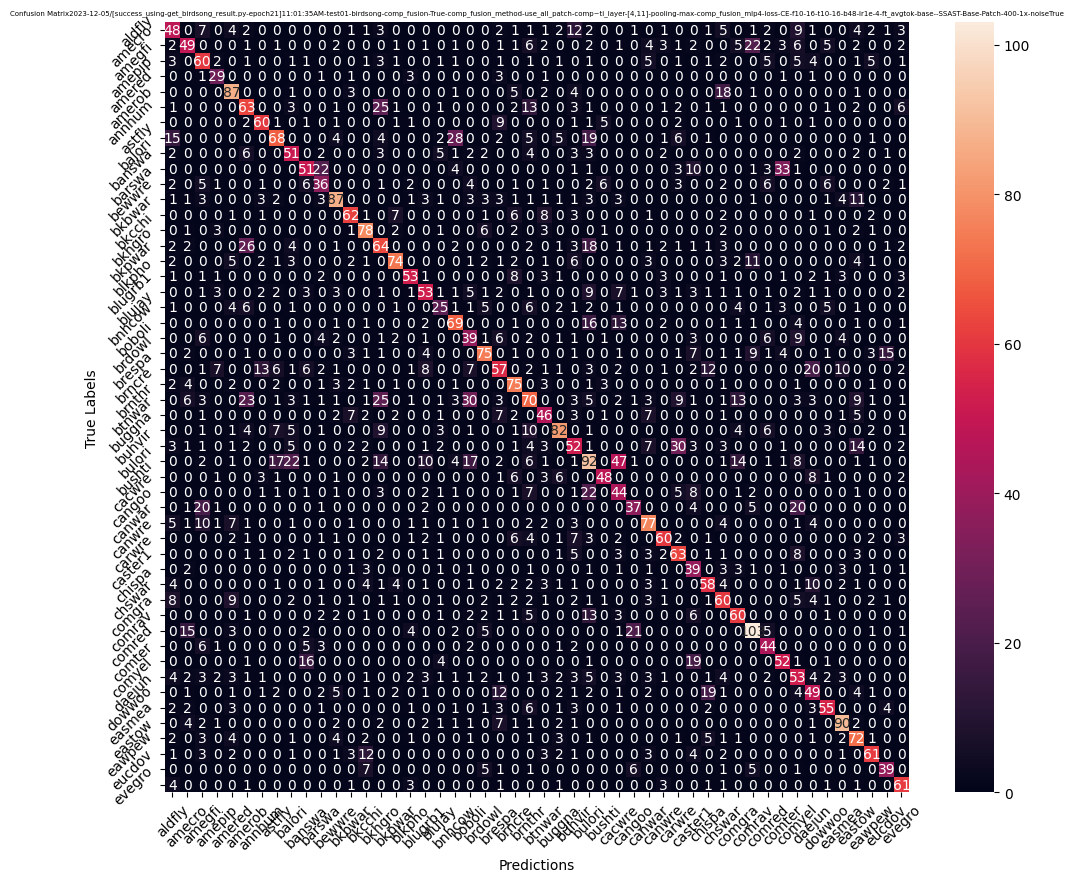

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# print(pred_labels)
cm = confusion_matrix(test_labels,pred_labels)

df_cm = pd.DataFrame(cm, index = [i for i in labels_arr],
                columns = [i for i in labels_arr])

# fig = plt.figure()
fig = plt.figure(figsize = (12,10))
sn.heatmap(df_cm, annot=True, fmt='g') #[Hyosun] fmt='g' added to remove e from the count
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Confusion Matrix'+result_dir, fontdict={'fontsize': 5}, loc='center', )
# fig.savefig('confusion_matrix.jpg')

fig.savefig('CornellBirdcall_conf_mat.png',dpi=300)



In [58]:
best_epoch_1

18

In [59]:
best_epoch_1+1 #[Hyosun] real best epoch

19

In [60]:
results[best_epoch_1,0] #[Hyosun] real best acc

'7.886178861788617489e-01'

In [61]:
        # if main_metrics == 'mAP':
        #     result[epoch-1, :] = [mAP, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_mAP, cum_mAUC, optimizer.param_groups[0]['lr']]
        # else:
        #     result[epoch-1, :] = [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
        # np.savetxt(exp_dir + '/result.csv', result, delimiter=',')
        # print('validation finished')

- result.csv에 들어가는 10 column들 순서:
    - [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
